In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### As test data doesn't have labels, we will split the train data [80,20]

In [4]:
df = pd.read_csv('/kaggle/input/playground-series-s6e2/train.csv')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [6]:
df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [7]:
from sklearn.model_selection import train_test_split

### Encoding y labels to 0 & 1 (presence=1)

In [8]:
X = df.drop(columns=['id','Heart Disease'])
y = df['Heart Disease']

In [9]:
y = y.map({'Presence':1,'Absence':0})
y.head()

0    1
1    0
2    0
3    0
4    1
Name: Heart Disease, dtype: int64

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
625149,54,1,4,110,274,0,0,125,1,0.4,1,0,7
276435,59,0,3,145,197,0,2,179,0,0.0,3,0,3
43949,64,0,4,160,204,0,0,125,0,0.0,2,0,7
280523,51,0,3,125,248,0,0,188,0,0.0,1,0,3
619977,64,0,4,130,204,0,2,138,0,0.0,1,0,3


In [11]:
from sklearn.preprocessing import StandardScaler

### Scaling features (StandardScaler)

In [12]:
num_cols = X_train.select_dtypes(include='number').columns
num_cols

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium'],
      dtype='object')

In [13]:
sc = StandardScaler()
sc.fit(X_train[num_cols])

StandardScaler()

In [14]:
X_train[num_cols] = sc.transform(X_train[num_cols])
X_test[num_cols] = sc.transform(X_test[num_cols])
X_train.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
625149,-0.016521,0.631521,0.806509,-1.367621,0.862166,-0.294928,-0.982791,-1.456751,1.629607,-0.332786,-0.836433,-0.564872,1.221070
276435,0.588907,-1.583479,-0.368138,0.969951,-1.425245,-0.294928,1.019633,1.368821,-0.613645,-0.754717,2.831988,-0.564872,-0.830314
43949,1.194335,-1.583479,0.806509,1.971768,-1.217299,-0.294928,-0.982791,-1.456751,-0.613645,-0.754717,0.997778,-0.564872,1.221070
280523,-0.379778,-1.583479,-0.368138,-0.365805,0.089793,-0.294928,-0.982791,1.839749,-0.613645,-0.754717,-0.836433,-0.564872,-0.830314
619977,1.194335,-1.583479,0.806509,-0.031866,-1.217299,-0.294928,1.019633,-0.776521,-0.613645,-0.754717,-0.836433,-0.564872,-0.830314


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [16]:
from sklearn.model_selection import GridSearchCV , KFold, cross_val_score

### KFold Cross validation to select the best model 

In [17]:
kf = KFold(n_splits=5,random_state=42,shuffle=True)

In [18]:
def cross_val(model, X, y, cv):
    scores = cross_val_score(estimator = model,
                             X=X,
                             y=y,
                             scoring='accuracy',
                             cv=cv,
                             n_jobs=-1,
                            )
    print(f'Scores of Model {model} are : {scores}\n')
    print(f'Average Score : {scores.mean()}\n')
    print(f'Standard Deviation of scores: {scores.std()}\n')

In [19]:
cross_val(model=LogisticRegression(),X=X_train,y=y_train,cv=kf)

Scores of Model LogisticRegression() are : [0.88274802 0.8821131  0.88380952 0.88452381 0.88386905]

Average Score : 0.8834126984126985

Standard Deviation of scores: 0.0008638361169727958



In [20]:
cross_val(model=RandomForestClassifier(),X=X_train,y=y_train,cv=kf)

Scores of Model RandomForestClassifier() are : [0.88070437 0.88098214 0.88195437 0.88110119 0.88126984]

Average Score : 0.881202380952381

Standard Deviation of scores: 0.00041875891931024927



In [21]:
cross_val(model=XGBClassifier(),X=X_train,y=y_train,cv=kf)

Scores of Model XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) are : [0.88809524 0.8862004  0.88865079 0.889375   0.88784722]

Average Score : 0.8880337301587303

Standard Deviation of scores: 0.0010563571070506994



In [22]:
rf = RandomForestClassifier()

### HyperParameter tuning of best model, to get best parameters (GridSearchCV)

In [23]:
param_grid = {
    'n_estimators':[50,100,200],
    'max_depth' : [None,10,50],
    'max_features' : ['sqrt','log2']
}

In [24]:
grid = GridSearchCV(estimator=rf, param_grid=param_grid, scoring='accuracy',cv= kf, n_jobs=-1)

In [25]:
grid.fit(X=X_train, y=y_train)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 50],
                         'max_features': ['sqrt', 'log2'],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [26]:
model = grid.best_estimator_
model

RandomForestClassifier(max_depth=10, max_features='log2', n_estimators=200)

In [27]:
y_pred = model.predict(X_test)

In [28]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [29]:
report = classification_report(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

In [30]:
print(f'Accuracy Score : {acc}\n')
print(f'Classification Report : \n{report}\n')
print(f'Confusion Matrix : \n{cm}\n')

Accuracy Score : 0.8842777777777778

Classification Report : 
              precision    recall  f1-score   support

           0       0.89      0.90      0.90     69564
           1       0.88      0.86      0.87     56436

    accuracy                           0.88    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.88      0.88      0.88    126000


Confusion Matrix : 
[[62880  6684]
 [ 7897 48539]]



<Axes: >

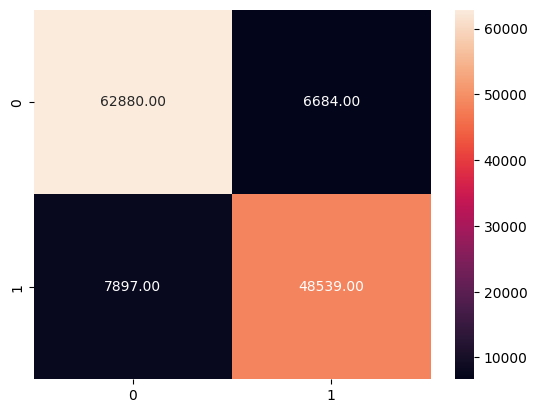

In [31]:
sns.heatmap(data=cm, annot=True, fmt='.2f')

In [32]:
test = pd.read_csv('/kaggle/input/playground-series-s6e2/test.csv')
test.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,630000,58,1,3,120,288,0,2,145,1,0.8,2,3,3
1,630001,55,0,2,120,209,0,0,172,0,0.0,1,0,3
2,630002,54,1,4,120,268,0,0,150,1,0.0,2,3,7
3,630003,44,0,3,112,177,0,0,168,0,0.9,1,0,3
4,630004,43,1,1,138,267,0,0,163,0,1.8,2,0,7


In [34]:
test2 = test.drop(columns=['id'])

In [35]:
test2[num_cols] = sc.transform(test2[num_cols])
test2.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,0.467821,0.631521,-0.368138,-0.699744,1.278059,-0.294928,1.019633,-0.410243,1.629607,0.089145,0.997778,3.192507,-0.830314
1,0.104564,-1.583479,-1.542785,-0.699744,-1.068766,-0.294928,-0.982791,1.002543,-0.613645,-0.754717,-0.836433,-0.564872,-0.830314
2,-0.016521,0.631521,0.806509,-0.699744,0.683926,-0.294928,-0.982791,-0.148616,1.629607,-0.754717,0.997778,3.192507,1.221070
3,-1.227378,-1.583479,-0.368138,-1.234046,-2.019378,-0.294928,-0.982791,0.793241,-0.613645,0.194628,-0.836433,-0.564872,-0.830314
4,-1.348464,0.631521,-2.717432,0.502437,0.654219,-0.294928,-0.982791,0.531614,-0.613645,1.143973,0.997778,-0.564872,1.221070


In [36]:
preds = model.predict(test2)
preds

array([1, 0, 1, ..., 0, 0, 0])

In [37]:
submission = pd.DataFrame({
    "id": test["id"],
    "Heart Disease": preds
})
submission.head()

,id,Heart Disease
0,630000,1
1,630001,0
2,630002,1
3,630003,0
4,630004,0


In [38]:
submission.to_csv("submission.csv", index=False)
